In [28]:
import pandas as pd


df_combined = pd.read_excel("bee_data_with_features.xlsx")
df_combined = df_combined.sample(frac=1).reset_index(drop=True)


In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import numpy as np
import pandas as pd

# Features and labels
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])
y = df_combined["queen acceptance"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split

# Encode y labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split on encoded y
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Use the integer labels for class_weight as well
class_weight = {
    le.transform([0])[0]: 1,
    le.transform([2])[0]: 1,
    le.transform([1])[0]: 1.5
}
# Compute class weights to handle imbalance
# class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {i: w for i, w in zip(np.unique(y_train), class_weight)}

# LightGBM classifier with weights
# lgbm = lgb.LGBMClassifier(class_weight=weight_dict, random_state=42)
lgbm = lgb.LGBMClassifier(
    num_leaves=15,
    max_depth=5,
    min_child_samples=30,
    class_weight=weight_dict,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l1=0.5,
    lambda_l2=0.5
)

# Hyperparameter tuning (optional, for speed can be skipped initially)
param_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}
grid = GridSearchCV(lgbm, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)

# Final prediction
y_pred = grid.best_estimator_.predict(X_test)

# Evaluation
print("Best Parameters:", grid.best_params_)
print(classification_report(y_test, y_pred))


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
print(y)

0        1
1        1
2        1
3        1
4        1
        ..
42595    2
42596    2
42597    2
42598    2
42599    2
Name: queen acceptance, Length: 42600, dtype: int64


In [30]:
from sklearn.metrics import classification_report

# Train set prediction
y_train_pred = grid.best_estimator_.predict(X_train)

# Evaluate on training set
print("\n--- Training Set Report ---")
print(classification_report(y_train, y_train_pred))

# Evaluate on test set (already done)
print("\n--- Test Set Report ---")
print(classification_report(y_test, y_pred))


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5

--- Training Set Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4530
           1       0.83      1.00      0.91      7413
           2       0.88      1.00      0.94     22137

    accuracy                           0.87     34080
   macro avg       0.57      0.67      0.61     34080
weighted avg       0.75      0.87      0.81     34080


--- Test Set Report ---
         

d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda 3\envs\installingrasa\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda 3

In [31]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-validation on full dataset (using scaled X and y)
cv_scores = cross_val_score(grid.best_estimator_, X_scaled, y, cv=5, scoring='f1_weighted')
print("\n--- Cross-Validation Scores (5-Fold, F1 Weighted) ---")
print("Scores:", cv_scores)
print("Mean:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

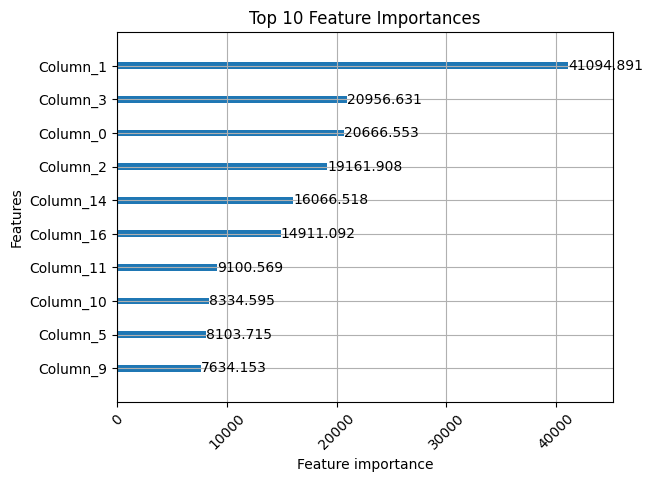

In [32]:
import matplotlib.pyplot as plt

# If you want to show feature names
feature_names = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"]).columns

lgb.plot_importance(grid.best_estimator_, max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importances")
plt.xticks(rotation=45)
plt.show()


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

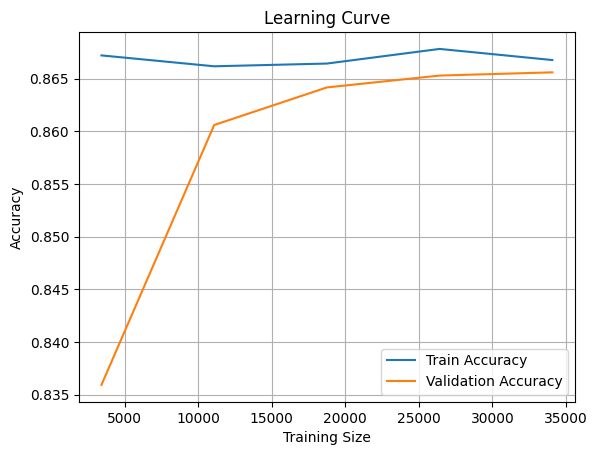

In [33]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(grid.best_estimator_, X_scaled, y, cv=5, scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
import joblib

# Create a dictionary of all components
model_package = {
    'model': grid.best_estimator_,
    'scaler': scaler,
    'label_encoder': le
}

# Save the entire package
joblib.dump(model_package, 'queen_acceptance_model_package.pkl')

['queen_acceptance_model_package.pkl']